# Tutorial 02 — Phân Tích Tần Số: FFT & Spectrogram

> **Mục tiêu:** Chuyển tín hiệu sang **miền tần số** để trả lời câu hỏi mà waveform không trả lời được: *"Ổ lăn hỏng ở **đâu** — rãnh trong, rãnh ngoài, hay viên bi?"*

---

## 🎯 Bạn sẽ học được gì?

| Kỹ năng | Áp dụng thực tế |
|---|---|
| Hiểu **FFT**: từ thời gian → tần số | Biết tín hiệu rung "chứa" những tần số nào |
| Đọc phổ FFT, định vị tần số đặc trưng lỗi | Đỉnh ở 162 Hz ⇒ nghi rãnh trong; 107 Hz ⇒ rãnh ngoài |
| Đọc **spectrogram** (bản đồ thời gian–tần số) | Thấy xung va chạm "nhấp nháy" theo chu kỳ |
| Biết **giới hạn của FFT thô** | Hiểu vì sao cần kỹ thuật nâng cao (envelope) |

## 🔑 Vì sao cần miền tần số?

Tutorial 01 cho thấy waveform phát hiện *có* xung, nhưng đếm khoảng cách xung bằng mắt rất khó. **FFT** làm việc đó tự động: nó phân tích tín hiệu thành tổng các sóng sin và cho biết **mỗi tần số mạnh cỡ nào**.

> 📌 **Liên hệ vật lý:** Lỗi rãnh ngoài tạo xung lặp đúng **BPFO ≈ 107 Hz** → trên phổ FFT (lý tưởng) sẽ thấy đỉnh tại 107 Hz và bội số của nó. Mỗi loại lỗi có một "tần số chữ ký" riêng.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import os

DATA_ROOT = "./data"
SAMPLE_RATE = 12000
plt.rcParams.update({'figure.figsize': (14, 4), 'figure.dpi': 100, 'font.size': 12})
print("OK!")


OK!


## 1. FFT là gì? — Ví dụ đơn giản

**FFT (Fast Fourier Transform)** biến tín hiệu từ **miền thời gian** sang **miền tần số**.

| | Miền thời gian | Miền tần số (sau FFT) |
|---|---|---|
| **Trục X** | Thời gian (ms) | Tần số (Hz) |
| **Trục Y** | Biên độ rung (g) | "Độ mạnh" của từng tần số |
| **Câu hỏi trả lời** | "Rung *khi nào*, hình dạng ra sao?" | "Rung *ở tần số nào*, mạnh cỡ nào?" |

> 💡 **Analogy:** Tai bạn nghe một hợp âm piano (tín hiệu trộn) nhưng não tách được từng nốt Đô–Mi–Sol. FFT làm đúng việc đó cho tín hiệu rung.

Thử nghiệm dưới đây trộn 2 sóng sin (50 Hz + 200 Hz) + nhiễu, rồi dùng FFT để **tách lại** đúng 2 đỉnh — chứng minh FFT "nhìn xuyên" được tín hiệu hỗn loạn.


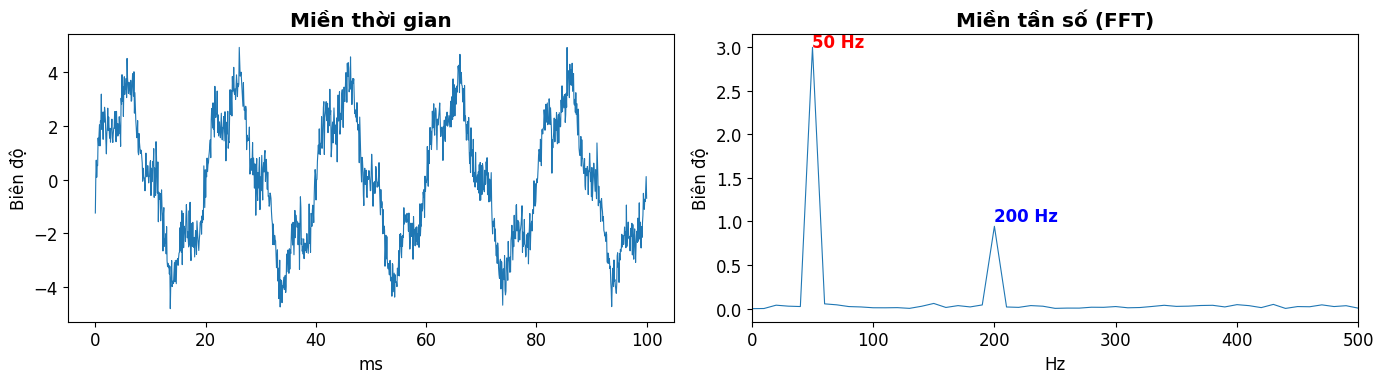

FFT tách rõ 2 thành phần tần số 50 Hz và 200 Hz từ tín hiệu trộn lẫn!


In [2]:
# Tạo tín hiệu gồm 2 sóng sin: 50 Hz và 200 Hz
t = np.linspace(0, 0.1, 1200)  # 0.1 giây, 12000 Hz
signal_demo = 3*np.sin(2*np.pi*50*t) + 1*np.sin(2*np.pi*200*t) + 0.5*np.random.randn(len(t))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Thời gian
axes[0].plot(t*1000, signal_demo, linewidth=0.8)
axes[0].set_title('Miền thời gian', fontweight='bold')
axes[0].set_xlabel('ms'); axes[0].set_ylabel('Biên độ')

# Tần số (FFT)
n = len(signal_demo)
yf = np.abs(fft(signal_demo)[:n//2]) * 2/n
freqs = fftfreq(n, 1/SAMPLE_RATE)[:n//2]
axes[1].plot(freqs, yf, linewidth=0.8)
axes[1].set_title('Miền tần số (FFT)', fontweight='bold')
axes[1].set_xlabel('Hz'); axes[1].set_ylabel('Biên độ')
axes[1].set_xlim([0, 500])
axes[1].annotate('50 Hz', xy=(50, 3), fontsize=12, color='red', fontweight='bold')
axes[1].annotate('200 Hz', xy=(200, 1), fontsize=12, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()
print("FFT tách rõ 2 thành phần tần số 50 Hz và 200 Hz từ tín hiệu trộn lẫn!")


## 2. FFT cho tín hiệu CWRU thực tế

Áp dụng FFT cho 4 trạng thái ổ lăn (0 HP, lỗi 7 mils).

> 📐 **Độ phân giải tần số:** Lấy `seg_len = 4096` mẫu ở 12 kHz → mỗi "vạch" phổ cách nhau $\Delta f = 12000/4096 ≈ 2.93$ Hz. Cửa sổ càng dài → phổ càng mịn (phân biệt được các đỉnh gần nhau), nhưng cần tín hiệu đủ ổn định trong cửa sổ đó.

**Kỳ vọng:**
- **Normal:** chủ yếu đỉnh ở tần số quay trục (~30 Hz ở 1797 RPM) và vài bội số, biên độ thấp.
- **IR / OR / Ball:** xuất hiện thêm năng lượng ở tần số đặc trưng lỗi **và vùng cộng hưởng tần số cao** (2–5 kHz) do xung va chạm kích thích.


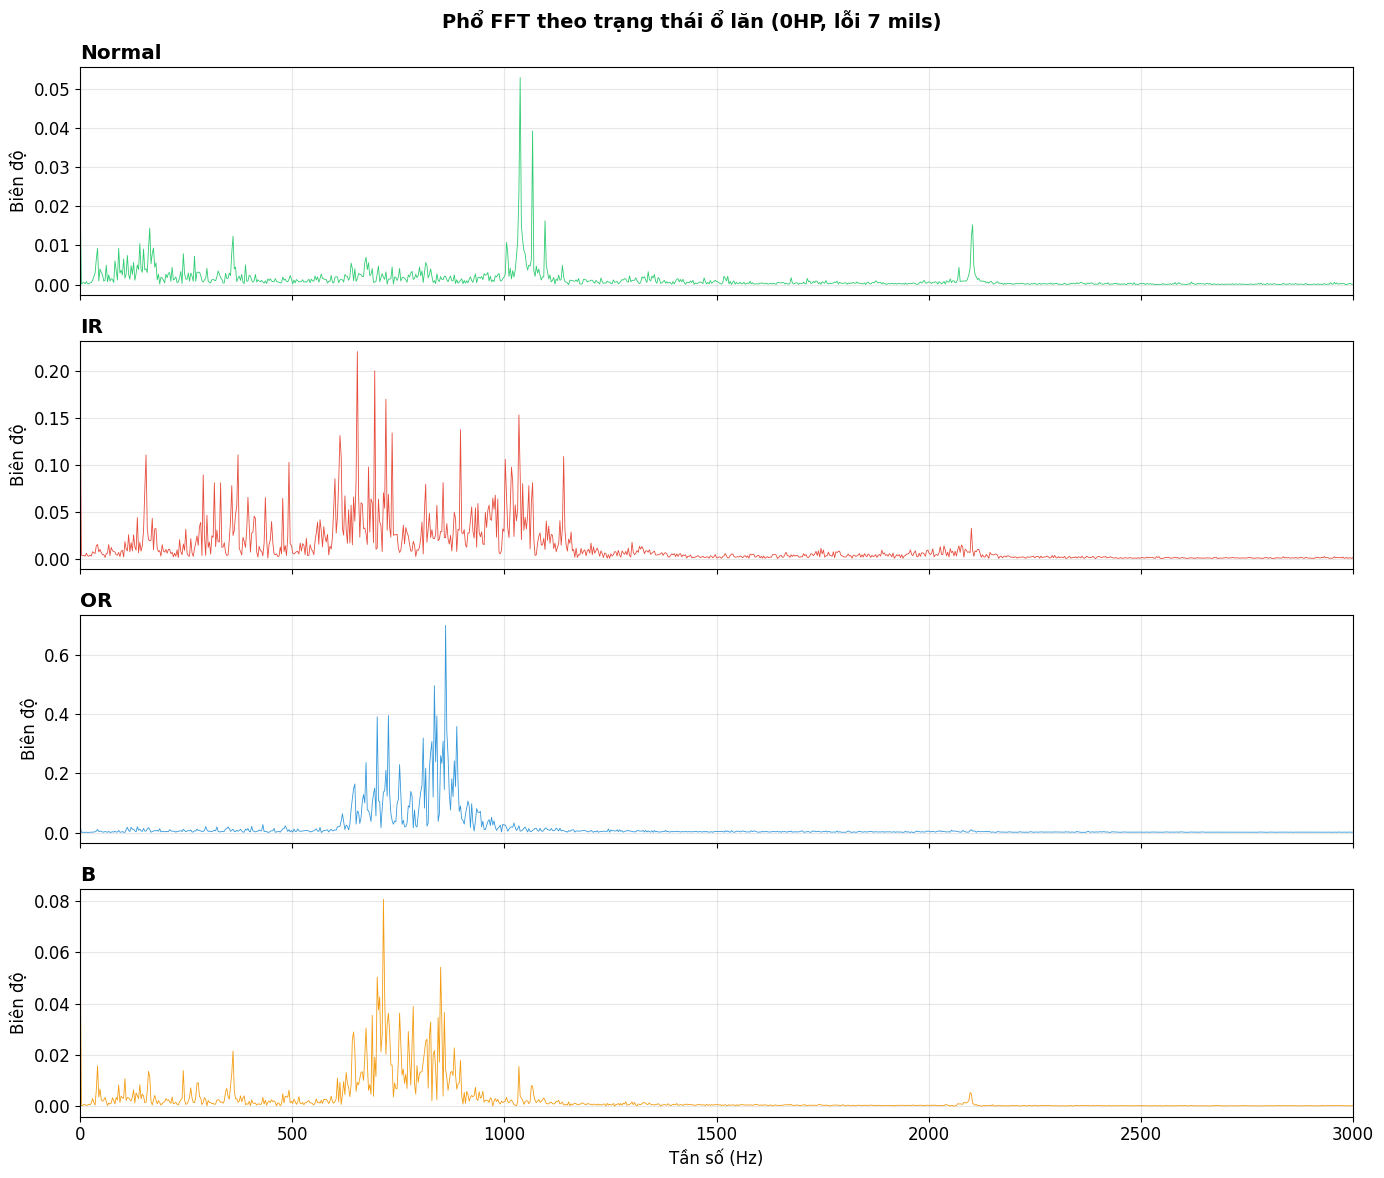

In [3]:
# Đọc dữ liệu
data = {}
for name, fname in [('Normal','Normal_DE.npy'), ('IR','IR_007_DE.npy'), 
                     ('OR','OR_007@6_DE.npy'), ('B','B_007_DE.npy')]:
    data[name] = np.load(os.path.join(DATA_ROOT, "0HP", fname))

# Lấy 1 đoạn 4096 mẫu để FFT (độ phân giải tần số = 12000/4096 ≈ 2.9 Hz)
seg_len = 4096
colors = {'Normal':'#2ecc71', 'IR':'#e74c3c', 'OR':'#3498db', 'B':'#f39c12'}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (name, sig) in zip(axes, data.items()):
    seg = sig[10000:10000+seg_len]
    yf = np.abs(fft(seg)[:seg_len//2]) * 2/seg_len
    freqs = fftfreq(seg_len, 1/SAMPLE_RATE)[:seg_len//2]
    ax.plot(freqs, yf, color=colors[name], linewidth=0.6)
    ax.set_ylabel('Biên độ')
    ax.set_title(name, fontweight='bold', loc='left')
    ax.set_xlim([0, 3000])
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Tần số (Hz)')
plt.suptitle('Phổ FFT theo trạng thái ổ lăn (0HP, lỗi 7 mils)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Tần số đặc trưng lỗi ổ lăn (Bearing Defect Frequencies)

Với ổ **SKF 6205-2RS** (CWRU drive end), tần số lỗi = hệ số × tần số quay trục $f_r$. Ở **0 HP (~1797 RPM)** → $f_r ≈ 29.95$ Hz:

| Ký hiệu | Tên | Hệ số × $f_r$ | Giá trị @1797 RPM |
|---|---|---|---|
| **BPFO** | Ball Pass Freq. Outer (rãnh ngoài) | 3.585 | **~107 Hz** |
| **BPFI** | Ball Pass Freq. Inner (rãnh trong) | 5.415 | **~162 Hz** |
| **BSF** | Ball (Spin) Fault (lỗi bi) | 4.714 | **~141 Hz** |
| **FTF** | Cage / Train Frequency (lồng bi) | 0.398 | **~12 Hz** |

→ Lỗi rãnh trong → đỉnh ở **BPFI** và bội số (2×, 3×…). Tương tự OR → **BPFO**, Ball → **BSF**.

> ⚠️ **Lưu ý BSF:** Con số ~141 Hz là tần số *lỗi* bi (đã ×2 so với tần số tự quay cơ bản ~70.6 Hz), vì vết lỗi trên bi đập vào **cả hai rãnh** mỗi vòng spin. Đây là quy ước CWRU công bố — ta giữ tên "BSF".
>
> ⚠️ **Khi tải tăng (RPM giảm)** mọi tần số trên **giảm theo tỉ lệ** — luôn tính lại theo RPM thực của bản ghi.


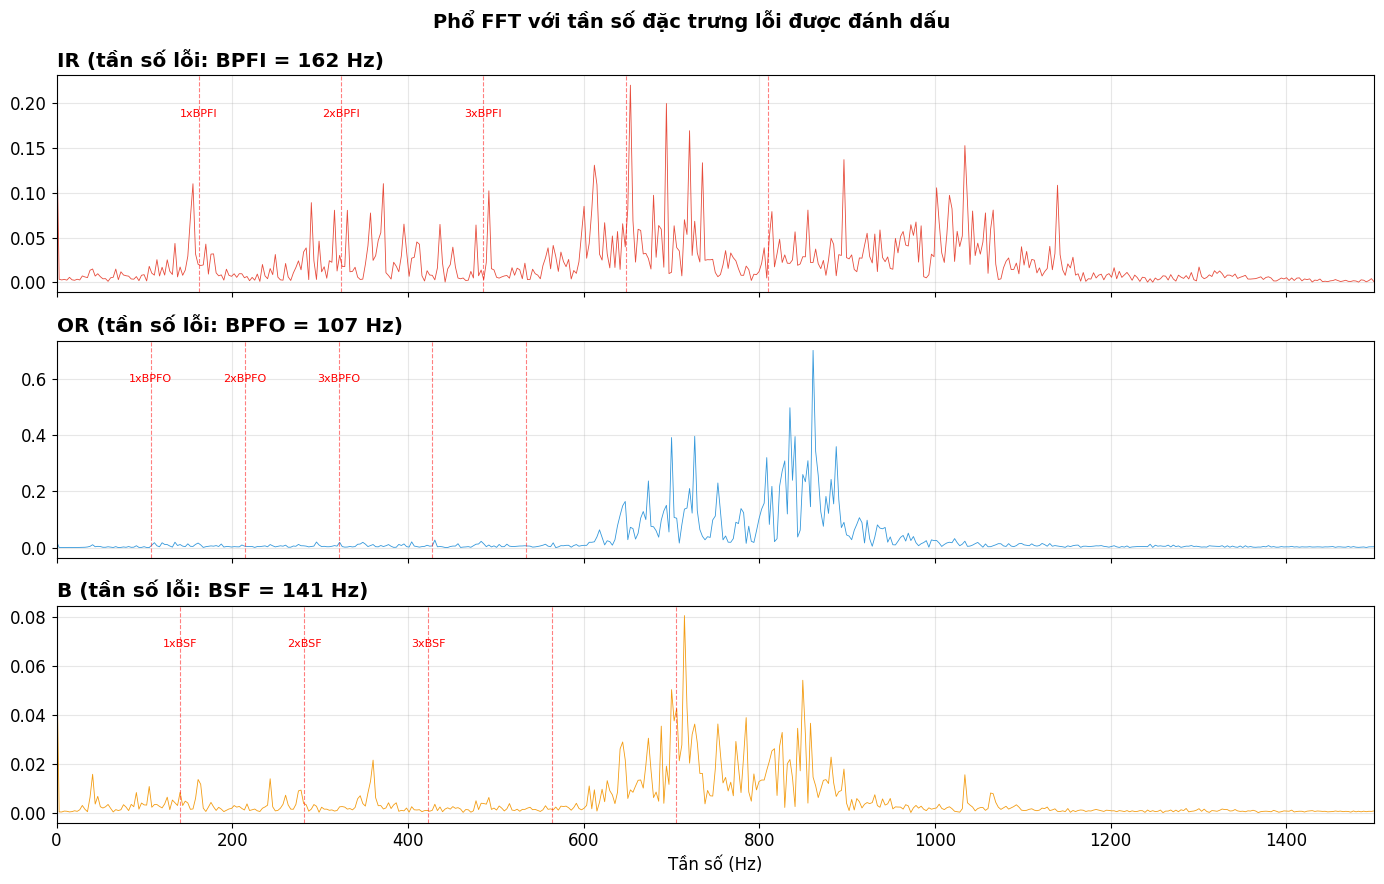

In [4]:
# Đánh dấu tần số đặc trưng lỗi trên phổ FFT
BPFO = 107; BPFI = 162; BSF = 141

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fault_info = [('IR', BPFI, 'BPFI'), ('OR', BPFO, 'BPFO'), ('B', BSF, 'BSF')]

for ax, (name, freq, label) in zip(axes, fault_info):
    seg = data[name][10000:10000+seg_len]
    yf = np.abs(fft(seg)[:seg_len//2]) * 2/seg_len
    freqs_arr = fftfreq(seg_len, 1/SAMPLE_RATE)[:seg_len//2]
    ax.plot(freqs_arr, yf, color=colors[name], linewidth=0.6)
    # Đánh dấu tần số lỗi và bội số
    for k in range(1, 6):
        ax.axvline(freq*k, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
        if k <= 3:
            ax.text(freq*k, ax.get_ylim()[1]*0.8 if ax.get_ylim()[1]>0 else 0.01, 
                    f'{k}x{label}', fontsize=8, color='red', ha='center')
    ax.set_title(f'{name} (tần số lỗi: {label} = {freq} Hz)', fontweight='bold', loc='left')
    ax.set_xlim([0, 1500]); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Tần số (Hz)')
plt.suptitle('Phổ FFT với tần số đặc trưng lỗi được đánh dấu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Spectrogram — Bản đồ thời gian–tần số

> ⚠️ **Giới hạn của FFT thô (rất quan trọng):** Trên phổ FFT của tín hiệu *gốc*, đỉnh tại BPFO/BPFI/BSF (vùng 100–200 Hz) **thường rất mờ**, bị chìm dưới thành phần quay trục biên độ lớn và nhiễu nền. Năng lượng xung va chạm thực ra dồn lên **vùng cộng hưởng 2–5 kHz**. Kỹ thuật chuyên dụng để "bóc" tần số lỗi là **Envelope Analysis** (lọc băng quanh vùng cộng hưởng → Hilbert → FFT của đường bao) — xem chi tiết trong tài liệu PhanA. Ở khóa này ta dùng đặc trưng năng lượng theo dải tần (Tutorial 03) thay cho envelope đầy đủ.

**Spectrogram** = FFT trên nhiều cửa sổ thời gian liên tiếp, ghép lại thành bản đồ nhiệt:

| Trục | Ý nghĩa |
|---|---|
| **X** | Thời gian |
| **Y** | Tần số |
| **Màu** | Năng lượng (sáng/vàng = mạnh, tối = yếu) |

> 💡 **Đọc spectrogram như kỹ sư:** Xung va chạm tuần hoàn hiện ra thành **các "sọc dọc" sáng lặp lại đều đặn**. Sọc càng đều, càng rõ → lỗi càng điển hình (OR rõ nhất, Ball mờ nhất). Đây là cách nhìn trực quan "nhịp va chạm" theo thời gian.


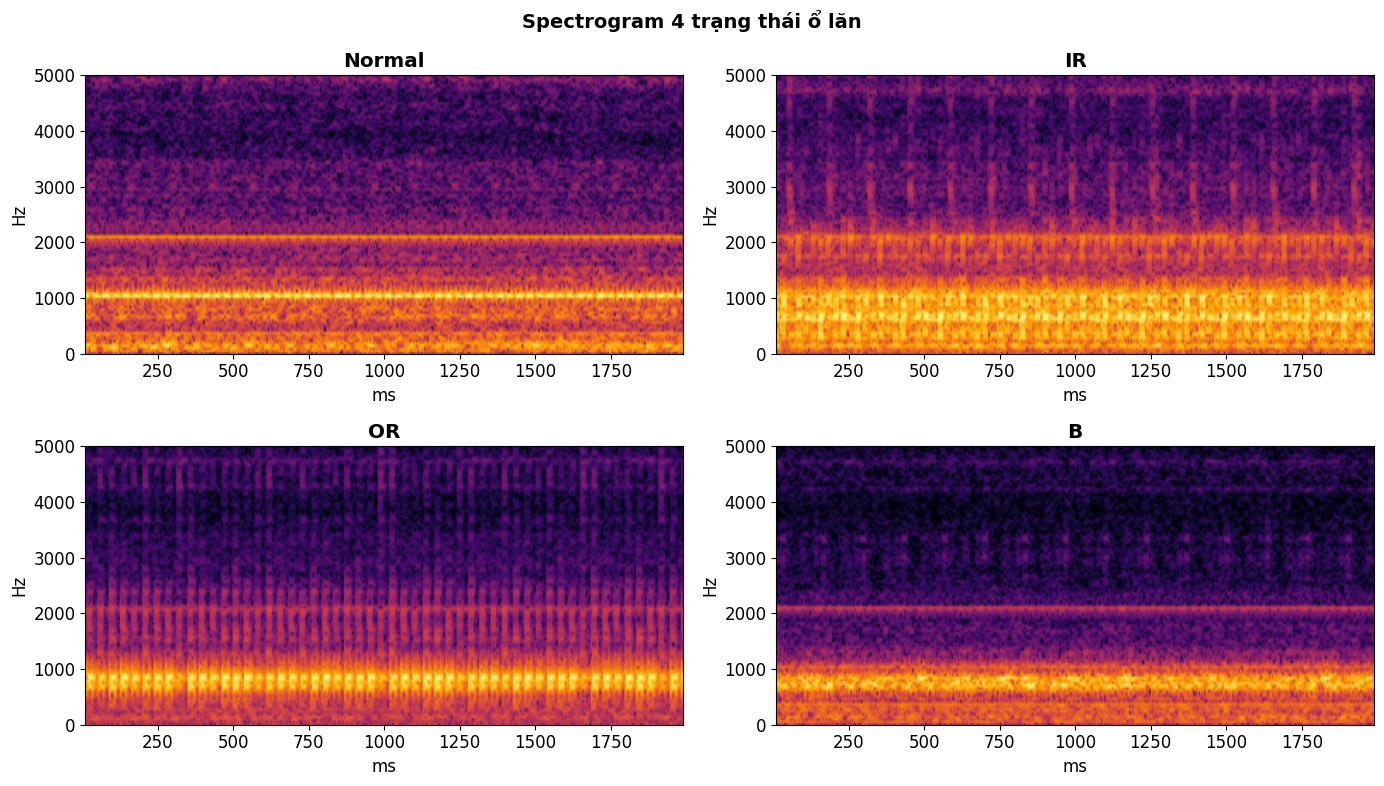

Nhận xét:
- Normal: màu đồng đều, năng lượng thấp
- IR/OR: sọc dọc lặp lại = xung va chạm kích thích năng lượng dải rộng
- B: sọc mờ hơn → lỗi bi khó phát hiện hơn


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, sig) in zip(axes, data.items()):
    seg = sig[:24000]  # 2 giây
    f, t_s, Sxx = spectrogram(seg, fs=SAMPLE_RATE, nperseg=256, noverlap=200)
    ax.pcolormesh(t_s*1000, f, 10*np.log10(Sxx+1e-10), shading='gouraud', cmap='inferno')
    ax.set_title(name, fontweight='bold')
    ax.set_ylim([0, 5000])
    ax.set_ylabel('Hz'); ax.set_xlabel('ms')

plt.suptitle('Spectrogram 4 trạng thái ổ lăn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("- Normal: màu đồng đều, năng lượng thấp")
print("- IR/OR: sọc dọc lặp lại = xung va chạm kích thích năng lượng dải rộng")
print("- B: sọc mờ hơn → lỗi bi khó phát hiện hơn")


## 📝 Tóm tắt & Key Takeaways

✅ **Bạn đã học:**
1. **FFT** trả lời "rung ở tần số nào" — tách tín hiệu trộn thành các thành phần.
2. Mỗi loại lỗi có **tần số chữ ký**: BPFO≈107, BPFI≈162, BSF≈141 Hz (@1797 RPM); tỉ lệ với RPM.
3. **Spectrogram** cho thấy xung va chạm "nhấp nháy" theo thời gian (sọc dọc).
4. **FFT thô có giới hạn** — đỉnh tần số lỗi mờ; cần envelope analysis hoặc đặc trưng dải tần.

🎯 **Thông điệp:** Miền tần số cho biết *hỏng ở đâu*, nhưng đọc phổ thủ công cho hàng nghìn bản ghi là bất khả thi → cần **trích đặc trưng số** (Tutorial 03) rồi để **máy học** tự phân loại (Tutorial 04).

---

## 🏋️ Bài tập

1. So sánh phổ FFT giữa `IR_007` và `IR_021` (lỗi nhẹ vs nặng) — đỉnh BPFI mạnh lên bao nhiêu?
2. Đổi `seg_len` (1024, 2048, 8192) → độ phân giải $\Delta f$ thay đổi ra sao? Tính thử.
3. Trên phổ FFT của OR, bạn có thấy đỉnh **rõ** ở BPFO=107 Hz không? Nếu mờ, giải thích bằng "giới hạn FFT thô" ở Mục 4.

---
*Tutorial 02/05 — Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
